## Decision Tree Classifier

It is a popular and versatile machine learning algorithm used for classification tasks.
It works by splitting the dataset into subsets based on the value of input features, creating a tree-like model of decisions.
used for both classification and regression model, mainly classification.

In [ ]:
          Is it raining?
            /     \
           Yes    No
          |      |
      Stay in     Is it hot?
                   /      \
                  Yes     No
                    |     |
                Stay in    Go out

# Key Components of a dicision tree

##### Root Node/parent node:
Represents the entire dataset and the initial decision to be made (at the top of the tree).
Splitting: Dividing a node into two or more sub-nodes based on the feature.

##### Internal/Decision node:
When a sub-node splits into further sub-nodes, it is called the decision node.

##### Branches:
Represent the outcome of a decision or test, leading to another node.

##### Leaf Nodes/Terminal:
Represent the final decision or prediction. No further splits occur at these nodes

## Working:
Decision trees use multiple algorithms to decide to split a node into two or 
more sub-nodes. If the dataset contains N attributes, then deciding which 
attribute to be place at the root or at different levels of the tree is done based 
on criteria like entropy, information gain etc.

#### The higher the entropy, the more randomness (impurity) a node has.
#### The attribute with the higher information gain is places at the root.
 
### Selecting the Best Attribute:
The algorithm uses metrics like Gini impurity, entropy, or information gain to select
the best attribute to split the data.

### Splitting the Dataset: 
The dataset is split into subsets based on the selected attribute.

### Repeating the Process:
This process is repeated recursively for each subset, creating new internal nodes or 
leaf nodes until a stopping criterion is met (e.g., all instances in a node belong to 
the same class or a predefined depth is reached).

### Gini Impurity:
It measures how often a randomly chosen element from the set would be incorrectly labeled if it were 
randomly labeled according to the distribution of labels in the subset.

Lower Gini = better split (more pure).

### Entropy: 
Entropy measures the level of disorder or impurity in the dataset. 
More uncertainty = higher entropy.
Entropy is 0 when all data belongs to one class(pure).

### Information Gain:
Information Gain tells us how much entropy is reduced after a split. 
The goal is to maximize IG when choosing splits.
higher better

### Pruning
To overcome: Features with more levels can overfitting, pruning techniques are used.
Pruning reduces the size of the tree by removing unwanted branches from the tree.

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
import warnings
from sklearn.svm import SVR
warnings.filterwarnings("ignore")
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn import tree

In [3]:
data=pd.read_csv("salaries.csv")
data.head()

,company,job,degree,salary_more_then_100k
0,google,sales executive,bachelors,0
1,google,sales executive,masters,0
2,google,business manager,bachelors,1
3,google,business manager,masters,1
4,google,computer programmer,bachelors,0


In [4]:
data.info

<bound method DataFrame.info of        company                  job     degree  salary_more_then_100k
0       google      sales executive  bachelors                      0
1       google      sales executive    masters                      0
2       google     business manager  bachelors                      1
3       google     business manager    masters                      1
4       google  computer programmer  bachelors                      0
5       google  computer programmer    masters                      1
6   abc pharma      sales executive    masters                      0
7   abc pharma  computer programmer  bachelors                      0
8   abc pharma     business manager  bachelors                      0
9   abc pharma     business manager    masters                      1
10    facebook      sales executive  bachelors                      1
11    facebook      sales executive    masters                      1
12    facebook     business manager  bachelors            

In [5]:
data.size

64

In [6]:
data.describe

<bound method NDFrame.describe of        company                  job     degree  salary_more_then_100k
0       google      sales executive  bachelors                      0
1       google      sales executive    masters                      0
2       google     business manager  bachelors                      1
3       google     business manager    masters                      1
4       google  computer programmer  bachelors                      0
5       google  computer programmer    masters                      1
6   abc pharma      sales executive    masters                      0
7   abc pharma  computer programmer  bachelors                      0
8   abc pharma     business manager  bachelors                      0
9   abc pharma     business manager    masters                      1
10    facebook      sales executive  bachelors                      1
11    facebook      sales executive    masters                      1
12    facebook     business manager  bachelors          

In [7]:
data.isnull()

,company,job,degree,salary_more_then_100k
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False
5,False,False,False,False
6,False,False,False,False
7,False,False,False,False
8,False,False,False,False
9,False,False,False,False


In [8]:
data.isnull().sum()

company                  0
job                      0
degree                   0
salary_more_then_100k    0
dtype: int64

In [9]:
data.duplicated()

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
dtype: bool

In [10]:
data.duplicated().sum()

np.int64(0)

In [11]:
data.shape

(16, 4)

In [12]:
x = data.drop("salary_more_then_100k" , axis = 1)
y = data["salary_more_then_100k"]

In [16]:
le=LabelEncoder()

In [18]:
x["company"]=le.fit_transform(x[["company"]])

In [20]:
x["job"]=le.fit_transform(x[["job"]])

In [21]:
x["degree"]=le.fit_transform(x[["degree"]])

In [22]:
x

,company,job,degree
0,2,2,0
1,2,2,1
2,2,0,0
3,2,0,1
4,2,1,0
5,2,1,1
6,0,2,1
7,0,1,0
8,0,0,0
9,0,0,1


In [23]:
model=DecisionTreeClassifier()

In [24]:
model.fit(x,y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [35]:
y_pred=model.predict(x)


In [36]:
y_pred

array([0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1])

In [37]:
pd.DataFrame({"actual y":y,"predicted":y_pred})

,actual y,predicted
0,0,0
1,0,0
2,1,1
3,1,1
4,0,0
5,1,1
6,0,0
7,0,0
8,0,0
9,1,1


In [38]:
y_pred=model.predict([[0,2,1]])
y_pred

array([0])

In [39]:
model1=DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=42)
model1.fit(x,y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [40]:
model1.score(x,y)

0.9375

In [41]:
from sklearn import tree

In [42]:
print(tree.export_text(model))  #returns tree in human readable from

|--- feature_0 <= 0.50
|   |--- feature_1 <= 0.50
|   |   |--- feature_2 <= 0.50
|   |   |   |--- class: 0
|   |   |--- feature_2 >  0.50
|   |   |   |--- class: 1
|   |--- feature_1 >  0.50
|   |   |--- class: 0
|--- feature_0 >  0.50
|   |--- feature_0 <= 1.50
|   |   |--- class: 1
|   |--- feature_0 >  1.50
|   |   |--- feature_1 <= 0.50
|   |   |   |--- class: 1
|   |   |--- feature_1 >  0.50
|   |   |   |--- feature_2 <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- feature_2 >  0.50
|   |   |   |   |--- feature_1 <= 1.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- feature_1 >  1.50
|   |   |   |   |   |--- class: 0



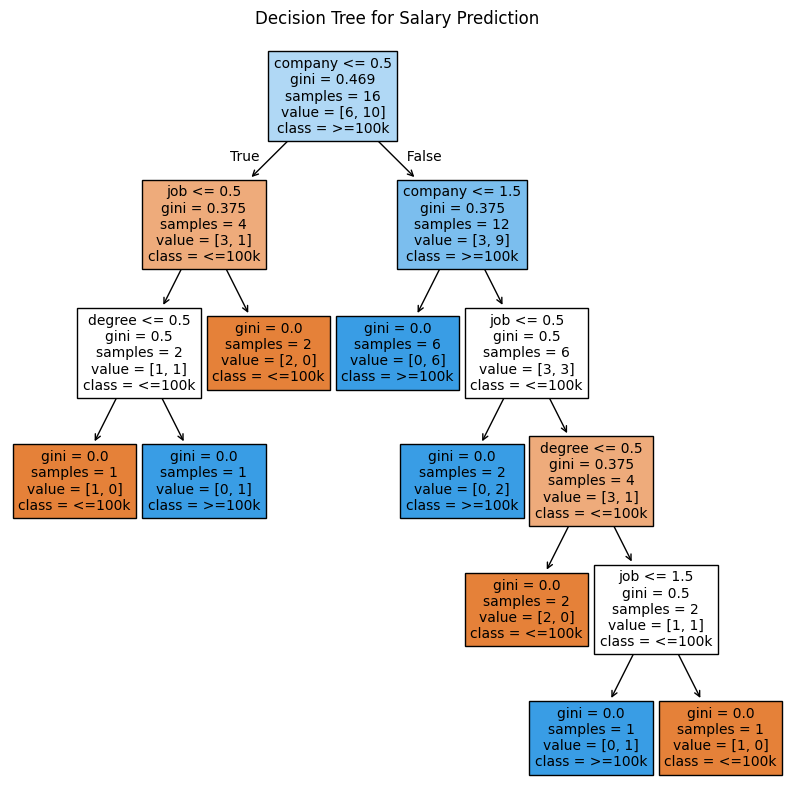

'class_names=["<=100", ">=100"] provides the names for the target classes.\nIn this case, it seems like the target variable has two classes: <=100 and >=100.'

In [43]:
fig = plt.figure(figsize=(10,10))
tree.plot_tree(model,feature_names=list(x.columns),class_names=["<=100k", ">=100k"],filled=True)
plt.title("Decision Tree for Salary Prediction")
plt.show()

"""feature_names=list(x.columns): specifies the names of the features used in the decision tree.
x.columns is assumed to be a DataFrame containing the feature names."""

"""class_names=["<=100", ">=100"] provides the names for the target classes.
In this case, it seems like the target variable has two classes: <=100 and >=100."""

#filled=True fills the nodes with colors to indicate the majority class in each node.

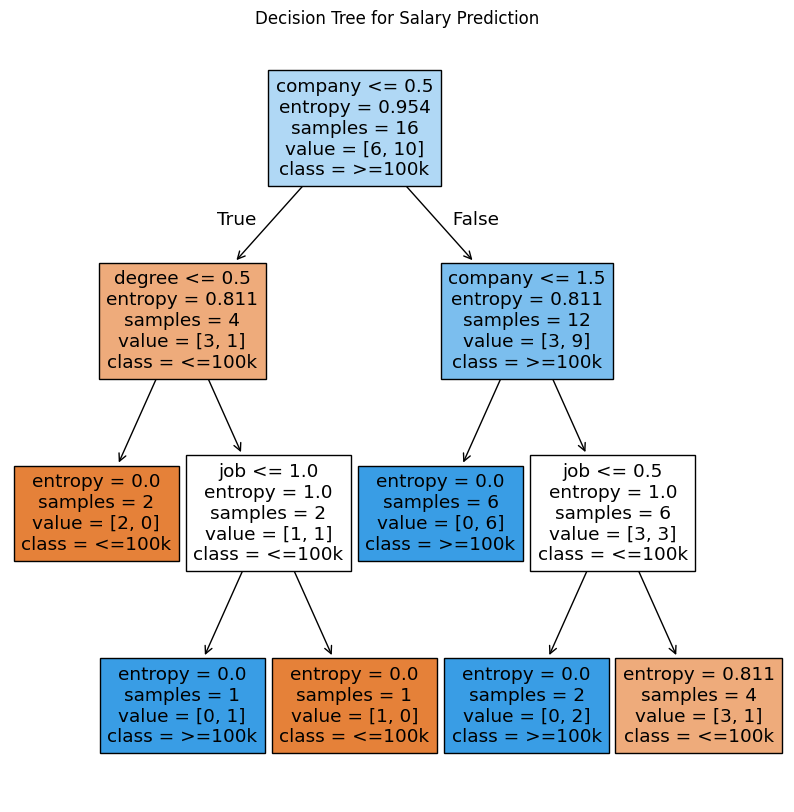

In [44]:
fig = plt.figure(figsize=(10,10))
tree.plot_tree(model1,feature_names=list(x.columns),class_names=["<=100k", ">=100k"],filled=True)
plt.title("Decision Tree for Salary Prediction")
plt.show()